In [18]:
import sys
sys.path.append("../") # Go up one level to project root 
#from src_test import drugbank_parse_fast
import pandas as pd
import zipfile
import xml.etree.ElementTree as ET
import random
import copy
import os
from collections import Counter
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

### 1. XML Parsing - get_all_approved_small_drugs()
* Streams through .xml.zip using ET.iterparse() + elem.clear() to avoid loading entire file into memory
* Reservoir sampling with copy.deepcopy() for truly random selection
* OS entropy seed (os.urandom) for reproduciliblity across team members
* Three filters applied:
  * elem.get('type') == 'small molecule'
  * elem.find(primary_id_tag) is not None
  * is_approved() helper checks group == 'approved'

In [33]:
def is_approved(drug_element, group_tag):
    """Check if a drug has 'approved' in its groups."""
    groups = drug_element.find(group_tag)
    if groups is None:
        return False
    return any(
        group.text.strip() == 'approved'
        for group in groups
        if group.text and group.text.strip()
    )

def get_all_approved_small_drugs(xml_zip_file):
    """ Stream through zipped DrugBank XML and collect ALL approved small molecule drugs."""

    drug_tag = f"{ns}drug"
    primary_id_tag = f"{ns}drugbank-id[@primary='true']"
    group_tag = f"{ns}groups"
    
    collected = []
    count = 0

    with zipfile.ZipFile(xml_zip_file,'r') as z:
        xml_filename = [f for f in z.namelist() if f.endswith('.xml')][0]
        print(f"Streaming: {xml_filename}")

        with z.open(xml_filename) as xml_file:
            for i, (event, elem) in enumerate(ET.iterparse(xml_file, events = ("end",))):
                #---- debugging ---
                if i < 20:
                    print(repr(elem.tag), elem.get('type'))
                # Only process top-level drug elements that have primary drugbank-id
                # Only include type = small molecule
                if (elem.tag == drug_tag and 
                    elem.get('type') == 'small molecule' and
                    elem.find(primary_id_tag) is not None and 
                    is_approved(elem, group_tag)):
                    count += 1

                    collected.append(copy.deepcopy(elem))
                    
                    if count%1000 == 0:
                        print(f" Scanned {count} approved small molecule drugs...")
                #elem.clear() # free memory - stays outside the if block
                        
    print(f"\n Total approved small molecule drugs scanned: {count} ")
    return collected

In [25]:
ns = "{http://www.drugbank.ca}"  
def print_drug_subtree(elem, indent=0):
    """Recursively print all tags, attributes, and text in a drug element."""
    tag = elem.tag.replace(ns, "")       # strip namespace for readability
    attrs = elem.attrib
    text  = elem.text.strip() if elem.text and elem.text.strip() else ""

    line = " " * indent + f"<{tag}"
    if attrs:
        line += " " + " ".join(f'{k}="{v}"' for k, v in attrs.items())
    line += ">"
    if text:
        line += f"  →  {text}"
    print(line)

    for child in elem:
        print_drug_subtree(child, indent + 2)


def test_get_one_drug(xml_zip_file):
    """
    Grab exactly ONE approved small molecule from the zip and print everything.
    Good for verifying:
      - namespace is correct
      - type filter works
      - approved filter works
      - all expected subtrees are present
    """
    drug_tag        = f"{ns}drug"
    primary_id_tag  = f"{ns}drugbank-id[@primary='true']"
    group_tag       = f"{ns}groups"

    with zipfile.ZipFile(xml_zip_file, 'r') as z:
        xml_filename = [f for f in z.namelist() if f.endswith('.xml')][0]
        print(f"Opening: {xml_filename}\n")

        with z.open(xml_filename) as xml_file:
            for event, elem in ET.iterparse(xml_file, events=("end",)):

                if (elem.tag == drug_tag and
                        elem.get('type') == 'small molecule' and
                        elem.find(primary_id_tag) is not None and
                        is_approved(elem, group_tag)):

                    drug_copy = copy.deepcopy(elem)
                    elem.clear()

                    # ── basic sanity checks ───────────────────────────────
                    db_id = drug_copy.find(primary_id_tag)
                    name  = drug_copy.find(f"{ns}name")

                    print("=" * 60)
                    print("SANITY CHECKS")
                    print("=" * 60)
                    print(f"  DrugBank ID : {db_id.text  if db_id  is not None else '*** MISSING ***'}")
                    print(f"  Name        : {name.text   if name   is not None else '*** MISSING ***'}")
                    print(f"  Type attr   : {drug_copy.get('type')}")

                    # confirm 'approved' is actually in groups
                    groups_elem = drug_copy.find(group_tag)
                    group_texts = [g.text.strip() for g in groups_elem
                                   if g.text and g.text.strip()] if groups_elem is not None else []
                    print(f"  Groups      : {group_texts}")
                    print()

                    # ── full subtree dump ─────────────────────────────────
                    print("=" * 60)
                    print("FULL SUBTREE")
                    print("=" * 60)
                    print_drug_subtree(drug_copy)
                    return drug_copy   # stop after the first hit

                elem.clear()

    print("No matching drug found — check your namespace or filters.")
    return None

In [26]:
drug = test_get_one_drug("../data/raw/drugbank_all_full_database_V5.1.14.xml.zip")

Opening: full database.xml

No matching drug found — check your namespace or filters.


In [27]:
with zipfile.ZipFile("../data/raw/drugbank_all_full_database_V5.1.14.xml.zip", 'r') as z:
    xml_name = [f for f in z.namelist() if f.endswith('.xml')][0]
    with z.open(xml_name) as f:
        for i, line in enumerate(f):
            print(line.decode('utf-8', errors='replace'))
            if i > 5: break

<?xml version="1.0" encoding="UTF-8"?>

<drugbank xmlns="http://www.drugbank.ca" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.drugbank.ca http://www.drugbank.ca/docs/drugbank.xsd" version="5.1" exported-on="2026-01-04">

<drug type="biotech" created="2005-06-13" updated="2025-11-04">

  <drugbank-id primary="true">DB00001</drugbank-id>

  <drugbank-id>BTD00024</drugbank-id>

  <drugbank-id>BIOD00024</drugbank-id>

  <name>Lepirudin</name>



In [31]:
def diagnose_filters(xml_zip_file, max_drugs=50):
    """Check the first max_drugs drug elements and report which filter blocks them."""
    drug_tag       = f"{ns}drug"
    primary_id_tag = f"{ns}drugbank-id[@primary='true']"
    group_tag      = f"{ns}groups"

    drug_count = 0

    with zipfile.ZipFile(xml_zip_file, 'r') as z:
        xml_name = [f for f in z.namelist() if f.endswith('.xml')][0]
        with z.open(xml_name) as f:
            for event, elem in ET.iterparse(f, events=("end",)):
                if elem.tag != drug_tag:
                    elem.clear()
                    continue

                drug_count += 1
                if drug_count > max_drugs:
                    break

                db_id  = elem.find(primary_id_tag)
                name   = elem.find(f"{ns}name")
                dtype  = elem.get('type')
                groups = elem.find(group_tag)
                group_texts = (
                    [g.text.strip() for g in groups if g.text and g.text.strip()]
                    if groups is not None else []
                )

                label = (name.text or "???") if name is not None else "???"

                # Report which filter each drug fails
                fail_reasons = []
                if dtype != 'small molecule':
                    fail_reasons.append(f"type='{dtype}'")
                if db_id is None:
                    fail_reasons.append("no primary ID")
                if 'approved' not in group_texts:
                    fail_reasons.append(f"groups={group_texts}")

                status = "PASS ✓" if not fail_reasons else "FAIL — " + ", ".join(fail_reasons)
                print(f"[{drug_count:3d}] {label:30s}  {status}")

                elem.clear()

    print(f"\nInspected {drug_count} drugs total.")

In [32]:
diagnose_filters("../data/raw/drugbank_all_full_database_V5.1.14.xml.zip", max_drugs=50)

[  1] ???                             FAIL — type='None', no primary ID, groups=[]
[  2] ???                             FAIL — type='None', no primary ID, groups=[]
[  3] ???                             FAIL — type='None', no primary ID, groups=[]
[  4] ???                             FAIL — type='biotech', no primary ID, groups=[]
[  5] ???                             FAIL — type='None', no primary ID, groups=[]
[  6] ???                             FAIL — type='biotech', no primary ID, groups=[]
[  7] ???                             FAIL — type='biotech', no primary ID, groups=[]
[  8] ???                             FAIL — type='biotech', no primary ID, groups=[]
[  9] ???                             FAIL — type='biotech', no primary ID, groups=[]
[ 10] ???                             FAIL — type='None', no primary ID, groups=[]
[ 11] ???                             FAIL — type='None', no primary ID, groups=[]
[ 12] ???                             FAIL — type='None', no primary ID,

In [ ]:
def diagnose_filters(xml_zip_file, max_drugs=50):
    drug_tag       = f"{ns}drug"
    primary_id_tag = f"{ns}drugbank-id[@primary='true']"
    group_tag      = f"{ns}groups"

    drug_count = 0
    inside_drug = False
    current_drug = None

    with zipfile.ZipFile(xml_zip_file, 'r') as z:
        xml_name = [f for f in z.namelist() if f.endswith('.xml')][0]
        with z.open(xml_name) as f:
            for event, elem in ET.iterparse(f, events=("start", "end")):  # need BOTH events

                if event == "start" and elem.tag == drug_tag:
                    inside_drug = True
                    current_drug = elem       # hold reference, don't clear yet

                elif event == "end" and elem.tag == drug_tag:
                    inside_drug = False
                    drug_count += 1
                    if drug_count > max_drugs:
                        break

                    db_id  = current_drug.find(primary_id_tag)
                    name   = current_drug.find(f"{ns}name")
                    dtype  = current_drug.get('type')
                    groups = current_drug.find(group_tag)
                    group_texts = (
                        [g.text.strip() for g in groups if g.text and g.text.strip()]
                        if groups is not None else []
                    )

                    label = (name.text or "???") if name is not None else "NO_NAME_TAG"

                    fail_reasons = []
                    if dtype != 'small molecule':
                        fail_reasons.append(f"type='{dtype}'")
                    if db_id is None:
                        fail_reasons.append("no primary ID")
                    if 'approved' not in group_texts:
                        fail_reasons.append(f"groups={group_texts}")

                    status = "PASS ✓" if not fail_reasons else "FAIL — " + ", ".join(fail_reasons)
                    print(f"[{drug_count:3d}] {label:30s}  {status}")

                    current_drug.clear()   # NOW safe to clear — we're done with it

                elif event == "end" and not inside_drug:
                    elem.clear()           # clear non-drug elements freely

    print(f"\nInspected {drug_count} drugs total.")

diagnose_filters("../data/raw/drugbank_all_full_database_V5.1.14.xml.zip", max_drugs=50)

### 2. Field Configuration - text files
Three editable config files loaded via load_ddi_fields():
* ddi_relevant_fields.txt - whitelist of **top_level** fields to extract (depth 1 only)
* ddi_exlude_fields.text - blacklist of deep sub-fields to stop recursing into
* ddi_property_fields.txt - whitelist of specific calculated-properties and experimental-properties kinds to keep (e.g. SMILES, InChiKey, lopP)

In [2]:
# Only extract these top-level fields, everything else is ignored
def load_ddi_fields(filepath):
    """Read DDI relevant fields from a text file, ignoring comments and blank lines."""
    with open(filepath,'r') as f:
        fields = {
            line.strip()
            for line in f
            if line.strip() and not line.strip().startswith('#')
        }
    print(f"Loaded {len(fields)} DDI-relevant fields from {filepath}")
    return fields

### 3. DEDICATED_HANDLERS and extract function 
DrugBank fields fall into two fundamentally different categories, and applies different strategies to each. 

* 1. Generac recursion (extract_all) handles flat or shallow subtrees where the structure is simple and consistent enough that positional column expansion is meaningful.
* 2. Subtrees that are inherently lists of records -
     **drug-interactions, targets, atc-codes, reactions, external-identifiers, groups, etc.**
     These are intercepted before extract_all ever sees them and extracted into structured Pyhon lists or dicts instead.
     Each extraction function knows the schema of its subtree and pulls out exactly the fields that matter. 

In [4]:
def extract_atc_codes(drug_element):
    codes = []
    atc_elem = drug_element.find(f"{ns}atc-codes")
    if atc_elem is not None:
        for code in atc_elem.findall(f"{ns}atc-code"):
            levels = [
                {'code': lvl.get('code'), 'name': lvl.text.strip() if lvl.text else None}
                for lvl in code.findall(f"{ns}level")
            ]
            codes.append({
                'code'  : code.get('code'),
                'levels': levels,
            })
    return codes

def extract_targets(drug_element):
    targets = []
    targets_elem = drug_element.find(f"{ns}targets")
    if targets_elem is not None:
        for target in targets_elem.findall(f"{ns}target"):
            polypeptides = []
            for pp in target.findall(f"{ns}polypeptide"):
                ext_ids = {
                    ext.findtext(f"{ns}resource"): ext.findtext(f"{ns}identifier")
                    for ext in pp.findall(f".//{ns}external-identifier")
                }
                polypeptides.append({
                    'id'        : pp.get('id'),
                    'source'    : pp.get('source'),
                    'name'      : pp.findtext(f"{ns}name"),
                    'gene-name' : pp.findtext(f"{ns}gene-name"),
                    'organism'  : pp.findtext(f"{ns}organism"),
                    'ext_ids'   : ext_ids,
                })
            targets.append({
                'id'          : target.findtext(f"{ns}id"),
                'name'        : target.findtext(f"{ns}name"),
                'organism'    : target.findtext(f"{ns}organism"),
                'known-action': target.findtext(f"{ns}known-action"),
                'actions'     : [a.text for a in target.findall(f".//{ns}action")],
                'polypeptides': polypeptides,
            })
    return targets

def extract_drug_interactions(drug_element):
    interactions = []
    interactions_elem = drug_element.find(f"{ns}drug-interactions")
    if interactions_elem is not None:
        for interaction in interactions_elem.findall(f"{ns}drug-interaction"):
            interactions.append({
                'drugbank_id': interaction.findtext(f"{ns}drugbank-id"),
                'name'       : interaction.findtext(f"{ns}name"),
                'description': interaction.findtext(f"{ns}description"),
            })
    return interactions

def extract_reactions(drug_element):
    reactions = []
    reactions_elem = drug_element.find(f"{ns}reactions")
    if reactions_elem is not None:
        for rxn in reactions_elem.findall(f"{ns}reaction"):
            enzymes = [
                {
                    'drugbank-id': e.findtext(f"{ns}drugbank-id"),
                    'name'       : e.findtext(f"{ns}name"),
                    'uniprot-id' : e.findtext(f"{ns}uniprot-id"),
                }
                for e in rxn.findall(f".//{ns}enzyme")
            ]
            reactions.append({
                'sequence'     : rxn.findtext(f"{ns}sequence"),
                'left-element' : {
                    'drugbank-id': rxn.findtext(f".//{ns}left-element/{ns}drugbank-id"),
                    'name'       : rxn.findtext(f".//{ns}left-element/{ns}name"),
                },
                'right-element': {
                    'drugbank-id': rxn.findtext(f".//{ns}right-element/{ns}drugbank-id"),
                    'name'       : rxn.findtext(f".//{ns}right-element/{ns}name"),
                },
                'enzymes'      : enzymes,
            })
    return reactions

def extract_external_identifiers(drug_element):
    ext_ids_elem = drug_element.find(f"{ns}external-identifiers")
    if ext_ids_elem is None:
        return {}
    return {
        ext.findtext(f"{ns}resource"): ext.findtext(f"{ns}identifier")
        for ext in ext_ids_elem.findall(f"{ns}external-identifier")
    }

def extract_groups(drug_element):
    groups_elem = drug_element.find(f"{ns}groups")
    if groups_elem is None:
        return []
    return [g.text.strip() for g in groups_elem.findall(f"{ns}group") if g.text]

In [5]:
DEDICATED_HANDLERS = {
    'atc-codes': {
        'extractor': extract_atc_codes,
        'count_key': 'drug/n_atc_codes',
        'data_key' : 'drug/atc_codes',
    },
    'targets': {
        'extractor': extract_targets,
        'count_key': 'drug/n_targets',
        'data_key' : 'drug/targets',
    },
    'drug-interactions': {
        'extractor': extract_drug_interactions,
        'count_key': 'drug/n_interactions',
        'data_key' : 'drug/interactions',
    },
    'reactions': {
        'extractor': extract_reactions,
        'count_key': 'drug/n_reactions',
        'data_key' : 'drug/reactions',
    },
    'external-identifiers': {
        'extractor': extract_external_identifiers,
        'count_key': None,  # dict, not a list, so no count needed
        'data_key' : 'drug/external_identifiers',
    },
    'groups': {
        'extractor': extract_groups,
        'count_key': 'drug/n_groups',
        'data_key' : 'drug/groups',
    },
}

### 4. Drug Element Parsing - parse_drug_element()
Key design decisions:
* Depth 1 whitelist: only recurse into fields in DDI_RELEVANT_FIELDS
* Deep blacklist: immediately return if tag in EXCLUDE_FIELDS, stopping entire subtree
* Property filter: skip <property> elements whose <kind> is not in DDI_PROPERTY_FIELDS
* Use DEDICATED_HANDLERS: to store top-level elements that have extensive subtrees as structured lists.
* Numbered siblings: use Counter to detect repeated tags and number them tag[0], tag[1], etc.
* Drug interactions handled separately: stored as a compact list of dicts in a single cell instead of expanding into hundreds of columns

In [11]:
def parse_drug_element(drug_element): 
    """Recursively extract all data from a drug element into a flat dict.
    - ddi_relevant_fields: whitelist at depth 1
    - exclude_fields: blacklist at any depth
    - ddi_property_fields: whitelist for calculated/experimental property kinds
    Expanding multiple children with numbered indices.
    
    DEDICATED_HANDLERS: for any top-level elements that have extensive subtrees, extract as structured lists"""
    
    drug_data = {
        'drug/drugbank-id'      : drug_element.findtext(f"{ns}drugbank-id[@primary='true']"),
        'drug[@type]'           : drug_element.get('type'),
    }

    # Pre-populate placeholder keys for all dedicated handlers
    for handler_cfg in DEDICATED_HANDLERS.values():
        if handler_cfg['count_key'] is not None:
            drug_data[handler_cfg['count_key']] = 0
        drug_data[handler_cfg['data_key']]  = None

    # Generic recursive extractor for flat/shallow subtrees
    def extract_all(element, prefix=""):
        tag = element.tag.replace(ns, "")

        # Stop recursing into excluded subtrees
        if tag in EXCLUDE_FIELDS:
            return

        # For property elements, only keep whitelisted kinds
        if tag == 'property':
            kind = element.findtext(f"{ns}kind")
            if kind not in DDI_PROPERTY_FIELDS:
                return

        full_key = f"{prefix}/{tag}" if prefix else tag
        
        # get text content
        if element.text and element.text.strip():
            drug_data[full_key]=element.text.strip()
            
        # Get attributes
        for attr_name, attr_val in element.attrib.items():
            drug_data[f"{full_key}[@{attr_name}]"]= attr_val

        # Count all child tags in one pass
        children = list(element)
        tag_counts = Counter(c.tag.replace(ns,"") for c in children)
        tag_index = {}
        
        for child in children:
            child_tag = child.tag.replace(ns,"")
            if tag_counts[child_tag] > 1:
                idx = tag_index.get(child_tag, 0)
                tag_index[child_tag] = idx + 1
                extract_all(child, f"{full_key}/{child_tag}[{idx}]")
            else:
                extract_all(child, full_key)

    # Route each top-level child to the appropriate handler
    for child in drug_element: 
        child_tag = child.tag.replace(ns,"")
        
        if child_tag in DEDICATED_HANDLERS:
            cfg = DEDICATED_HANDLERS[child_tag]
            result = cfg['extractor'](child)
            if cfg['count_key'] is not None:
                drug_data[cfg['count_key']] = len(result)
            drug_data[cfg['data_key']]  = result if result else None
            
        elif child_tag in DDI_RELEVANT_FIELDS:
            extract_all(child, "drug")
            
    return drug_data

### 4. DataFrame Construction - drugs_to_dataframe()
Automatically benefits from all parse_drug_element() updates

In [7]:
def drugs_to_dataframe(xml_zip_file):
    """Save all drug data into a DataFrame."""

    drugs = get_all_approved_small_drugs(xml_zip_file)

    # Parse each drug into a dict, collect all dicts into a list
    records = []
    for drug_element in drugs:
        drug_data = parse_drug_element(drug_element)
        records.append(drug_data)

    # pd.DataFrame from a list of dicts automatically: 
    # - creates a column for every key seen across all drugs
    # - fills NaN where a drug doesn't have that field
    df = pd.DataFrame(records)

    df = df[df['drug/n_atc_codes']>0]

    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns ({len(df.columns)}):")
    for col in df.columns:
        non_null = df[col].notna().sum()
        print(f" {col}: {non_null}/{len(df)} drugs have data")

    return df 

### 5. DDI Eligibility Filtering - summarize_ddi_eligible_drugs()
* Uses drug/n_interactions > 0 for interaction check (fast integer comparison)
* Uses df.filter(like=...).notna().any(axis=1) for target check
* Includes Venndiagram visualization of overlap

In [8]:
def summarize_ddi_eligible_drugs(df):
    has_interaction = set(df[df['drug/n_interactions']>0].index)
    has_target = set(df[df['drug/n_targets']>0].index)

    eligible = has_interaction & has_target

    print(f"Total drugs sampled:                        {len(df)}")
    print(f"Drugs with at least one drug-interaction:   {len(has_interaction)}")
    print(f"Drugs with at least one target:             {len(has_target)}")
    print(f"Drugs with BOTH interaction and target:     {len(eligible)}")
    print(f"Drugs with interaction only (no target):    {len(has_interaction - has_target)}")
    print(f"Drugs with target only (no interaction):    {len(has_target - has_interaction)}")
    print(f"Drugs with neither:                         {len(df) - len(has_interaction | has_target)}")

    plt.figure(figsize=(8, 6))
    venn2(subsets=[has_interaction, has_target],
          set_labels=('Has Drug-Interaction', 'Has Target'))
    plt.title('Overlap between drugs with interactions and drugs with targets')
    plt.tight_layout()
    plt.savefig('ddi_target_overlap.png', dpi=150)
    plt.show()

    return df.loc[list(eligible)]

In [23]:
# Set your XML file path, 
## You have to add the zip file to this path since git repo doesn't track this large file
xml_path = "../data/raw/drugbank_all_full_database_V5.1.14.xml.zip"
ns = "{http://www.drugbank.ca}"

In [ ]:
DDI_RELEVANT_FIELDS = load_ddi_fields('../data/drugbank_ddi_relevant_fields.txt')
EXCLUDE_FIELDS = load_ddi_fields('../data/drugbank_ddi_exclude_fields.txt')
DDI_PROPERTY_FIELDS = load_ddi_fields('../data/drugbank_ddi_property_fields.txt')

df = drugs_to_dataframe(xml_path)

Loaded 14 DDI-relevant fields from ../data/drugbank_ddi_relevant_fields.txt
Loaded 15 DDI-relevant fields from ../data/drugbank_ddi_exclude_fields.txt
Loaded 2 DDI-relevant fields from ../data/drugbank_ddi_property_fields.txt
Streaming: full database.xml
'{http://www.drugbank.ca}drugbank-id' None
'{http://www.drugbank.ca}drugbank-id' None
'{http://www.drugbank.ca}drugbank-id' None
'{http://www.drugbank.ca}name' None
'{http://www.drugbank.ca}description' None
'{http://www.drugbank.ca}cas-number' None
'{http://www.drugbank.ca}unii' None
'{http://www.drugbank.ca}state' None
'{http://www.drugbank.ca}group' None
'{http://www.drugbank.ca}group' None
'{http://www.drugbank.ca}groups' None
'{http://www.drugbank.ca}ref-id' None
'{http://www.drugbank.ca}pubmed-id' None
'{http://www.drugbank.ca}citation' None
'{http://www.drugbank.ca}article' None
'{http://www.drugbank.ca}ref-id' None
'{http://www.drugbank.ca}pubmed-id' None
'{http://www.drugbank.ca}citation' None
'{http://www.drugbank.ca}article'

In [16]:
# Save to file
df.to_parquet("../data/sample/randomly_sampled_1000_drugs.parquet", index=False)
df = pd.read_parquet("../data/sample/randomly_sampled_1000_drugs.parquet")
print("\nSaved to ddi_prediction/data/sample")

# Transpose and disply top drugs as columns and their attributes as rows
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',50)
df.head(10).T


Saved to ddi_prediction/data/sample


,0,1,2,3,4,5,6,7,8,9
drug/drugbank-id,DB02351,BIOD00113,DB15673,APRD00843,DB11742,DB08948,DB12134,NUTR00045,EXPT00965,DB09371
drug[@type],small molecule,small molecule,small molecule,small molecule,small molecule,small molecule,small molecule,small molecule,small molecule,small molecule
drug/n_interactions,641,1156,400,317,813,0,616,0,789,541
drug/interactions,[{'description': 'Apixaban may increase the an...,[{'description': 'The therapeutic efficacy of ...,[{'description': 'The therapeutic efficacy of ...,[{'description': 'The metabolism of Eliglustat...,[{'description': 'The metabolism of Ebastine c...,None,[{'description': 'The serum concentration of G...,None,[{'description': 'The therapeutic efficacy of ...,[{'description': 'The therapeutic efficacy of ...
drug/n_targets,1,3,2,1,1,0,5,55,6,3
drug/targets,"[{'actions': ['inhibitor'], 'id': 'BE0000048',...","[{'actions': ['agonist'], 'id': 'BE0000134', '...","[{'actions': ['inhibitor'], 'id': 'BE0001594',...","[{'actions': ['antagonist'], 'id': 'BE0004803'...","[{'actions': ['antagonist'], 'id': 'BE0000442'...",None,"[{'actions': ['inhibitor'], 'id': 'BE0000798',...","[{'actions': ['inhibitor'], 'id': 'BE0000253',...","[{'actions': ['cofactor'], 'id': 'BE0000734', ...","[{'actions': [], 'id': 'BE0000123', 'known-act..."
drug/n_atc_codes,1,1,1,1,1,1,1,1,2,1
drug/atc_codes,"[{'code': 'B01AE06', 'levels': [{'code': 'B01A...","[{'code': 'L02AE03', 'levels': [{'code': 'L02A...","[{'code': 'J05AX31', 'levels': [{'code': 'J05A...","[{'code': 'G01AA04', 'levels': [{'code': 'G01A...","[{'code': 'R06AX22', 'levels': [{'code': 'R06A...","[{'code': 'V08AA03', 'levels': [{'code': 'V08A...","[{'code': 'J01XX13', 'levels': [{'code': 'J01X...","[{'code': 'A11HA06', 'levels': [{'code': 'A11H...","[{'code': 'B03BA01', 'levels': [{'code': 'B03B...","[{'code': 'G03FA09', 'levels': [{'code': 'G03F..."
drug/n_reactions,0,0,0,0,2,0,0,0,1,0
drug/reactions,None,None,None,None,"[{'enzymes': [{'drugbank-id': 'BE0002638', 'na...",None,None,None,"[{'enzymes': [], 'left-element': {'drugbank-id...",None


Total drugs sampled:                        746
Drugs with at least one drug-interaction:   667
Drugs with at least one target:             624
Drugs with BOTH interaction and target:     588
Drugs with interaction only (no target):    79
Drugs with target only (no interaction):    36
Drugs with neither:                         43


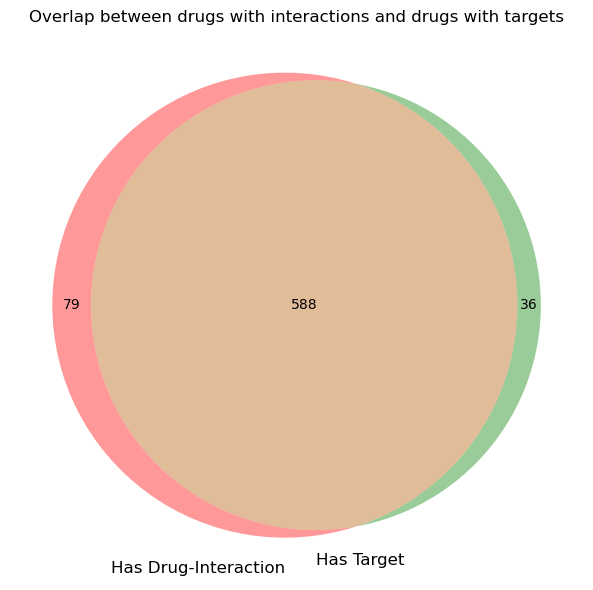

,drug/drugbank-id,drug[@type],drug/n_interactions,drug/interactions,drug/n_targets,drug/targets,drug/n_atc_codes,drug/atc_codes,drug/n_reactions,drug/reactions,...,drug/calculated-properties/property[5]/property/source,drug/calculated-properties/property[2]/property/kind,drug/calculated-properties/property[2]/property/value,drug/calculated-properties/property[2]/property/source,drug/calculated-properties/property[7]/property/kind,drug/calculated-properties/property[7]/property/value,drug/calculated-properties/property[7]/property/source,drug/calculated-properties/property[10]/property/kind,drug/calculated-properties/property[10]/property/value,drug/calculated-properties/property[10]/property/source
0,DB02351,small molecule,641,[{'description': 'Apixaban may increase the an...,1,"[{'actions': ['inhibitor'], 'id': 'BE0000048',...",1,"[{'code': 'B01AE06', 'levels': [{'code': 'B01A...",0,None,...,None,None,None,None,None,None,None,None,None,None
1,BIOD00113,small molecule,1156,[{'description': 'The therapeutic efficacy of ...,3,"[{'actions': ['agonist'], 'id': 'BE0000134', '...",1,"[{'code': 'L02AE03', 'levels': [{'code': 'L02A...",0,None,...,None,None,None,None,None,None,None,None,None,None
2,DB15673,small molecule,400,[{'description': 'The therapeutic efficacy of ...,2,"[{'actions': ['inhibitor'], 'id': 'BE0001594',...",1,"[{'code': 'J05AX31', 'levels': [{'code': 'J05A...",0,None,...,None,None,None,None,None,None,None,None,None,None
3,APRD00843,small molecule,317,[{'description': 'The metabolism of Eliglustat...,1,"[{'actions': ['antagonist'], 'id': 'BE0004803'...",1,"[{'code': 'G01AA04', 'levels': [{'code': 'G01A...",0,None,...,None,None,None,None,None,None,None,None,None,None
4,DB11742,small molecule,813,[{'description': 'The metabolism of Ebastine c...,1,"[{'actions': ['antagonist'], 'id': 'BE0000442'...",1,"[{'code': 'R06AX22', 'levels': [{'code': 'R06A...",2,"[{'enzymes': [{'drugbank-id': 'BE0002638', 'na...",...,None,None,None,None,None,None,None,None,None,None
6,DB12134,small molecule,616,[{'description': 'The serum concentration of G...,5,"[{'actions': ['inhibitor'], 'id': 'BE0000798',...",1,"[{'code': 'J01XX13', 'levels': [{'code': 'J01X...",0,None,...,None,None,None,None,None,None,None,None,None,None
8,EXPT00965,small molecule,789,[{'description': 'The therapeutic efficacy of ...,6,"[{'actions': ['cofactor'], 'id': 'BE0000734', ...",2,"[{'code': 'B03BA01', 'levels': [{'code': 'B03B...",1,"[{'enzymes': [], 'left-element': {'drugbank-id...",...,None,None,None,None,None,None,None,None,None,None
9,DB09371,small molecule,541,[{'description': 'The therapeutic efficacy of ...,3,"[{'actions': [], 'id': 'BE0000123', 'known-act...",1,"[{'code': 'G03FA09', 'levels': [{'code': 'G03F...",0,None,...,None,None,None,None,None,None,None,None,None,None
15,DB11317,small molecule,64,[{'description': 'Ascorbic acid can cause an i...,26,"[{'actions': ['modulator'], 'id': 'BE0000168',...",4,"[{'code': 'G01AD03', 'levels': [{'code': 'G01A...",6,"[{'enzymes': [], 'left-element': {'drugbank-id...",...,None,None,None,None,None,None,None,None,None,None
17,DB09112,small molecule,307,[{'description': 'The risk or severity of orth...,3,"[{'actions': ['oxidizer'], 'id': 'BE0000130', ...",1,"[{'code': 'V03AB08', 'levels': [{'code': 'V03A...",3,"[{'enzymes': [{'drugbank-id': 'BE0000130', 'na...",...,ChemAxon,None,None,None,None,None,None,None,None,None


In [17]:
summarize_ddi_eligible_drugs(df)